## P30 — cross-entropy loss curves for the five p27 sweeps

Loads the five P(correct) curves from `p27_sweep_k/curve.npy` (same colors / values as `p27_gradients`) and
adds the cross-entropy loss, `−ln P`, in two flavors. Every frame in this notebook shares **one** crop box, so the
axes sit on identical pixels across all prob-only, loss-only and combined frames.

```
p30_loss_separate/param_k/frame_NNN.png   loss curve only, transparent bg, left y-ticks, x-axis kept, no grid, draw-in L→R
p30_loss_separate/param_k/prob_only.png   matching P(correct) frame (black bg, same crop) to overlay onto in Premiere
p30_loss_combined/param_k/frame_NNN.png   P(correct) at alpha 0.5 (left axis, grid) + loss on a right axis, draw-in L→R
p30_*/param_k/loss.npy                    (3 x N): theta, P, loss
p30_*/param_k/summary.json                loss y-limits, color, w0, ...
```

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import json, gc, io
from pathlib import Path
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure                      # OO figures: never registered with the notebook backend -> no RAM creep
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.transforms import Bbox
from PIL import Image
from IPython.display import display

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

ROOT         = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin")
SWEEP_DIR    = lambda k: ROOT / f'p27_sweep_{k}'         # written by P25_37c
OUT_SEPARATE = ROOT / 'p30_loss_separate'
OUT_COMBINED = ROOT / 'p30_loss_combined'
SPAN         = 2.5
N_PARAMS     = 5

### Load curves, compute loss

In [3]:
LOSS_PAD_FRAC = 0.05          # y-padding as a fraction of the loss range (the prob axis uses -0.05..1.05, i.e. the same 5%)
P_FLOOR       = 1e-12         # clip before the log so P=0 can't give inf

params = {}
for k in range(1, N_PARAMS + 1):
    meta = json.load(open(SWEEP_DIR(k) / 'summary.json'))
    vals, res = np.load(SWEEP_DIR(k) / 'curve.npy')
    loss = -np.log(np.clip(res, P_FLOOR, None))
    lo, hi = loss.min(), loss.max(); pad = LOSS_PAD_FRAC * (hi - lo)
    plo, phi = res.min(), res.max(); ppad = LOSS_PAD_FRAC * (phi - plo)
    params[k] = dict(k=k, vals=vals, res=res, loss=loss, loss_ylim=(lo - pad, hi + pad), prob_ylim=(plo - ppad, phi + ppad), w0=meta['w0'],
                     color=meta['color'], theta_label=meta['theta_label'], coord=meta['coord'], layer_num=meta['layer_num'])

print(f"{'k':>2} {'coord':<22} {'color':<8} {'P range':<18} {'loss range':<18} loss ylim")
for p in params.values():
    print(f"{p['k']:>2} {str(tuple(p['coord'])):<22} {p['color']:<8} {p['res'].min():.4f} .. {p['res'].max():.4f}    "
          f"{p['loss'].min():.3f} .. {p['loss'].max():.3f}    {p['loss_ylim'][0]:.3f} .. {p['loss_ylim'][1]:.3f}")

 k coord                  color    P range            loss range         loss ylim
 1 (784, 103)             m        0.0000 .. 0.9874    0.013 .. 11.346    -0.554 .. 11.913
 2 (63, 10, 0, 0)         #eb8423  0.0223 .. 0.1695    1.775 .. 3.801    1.673 .. 3.902
 3 (59, 8, 0, 2)          #419c52  0.0001 .. 0.0714    2.640 .. 9.501    2.297 .. 9.844
 4 (34, 14, 2, 1)         #ed5e78  0.0018 .. 0.0611    2.795 .. 6.328    2.619 .. 6.504
 5 (33, 0, 6, 1)          #d73b2f  0.0399 .. 0.0679    2.690 .. 3.221    2.663 .. 3.248


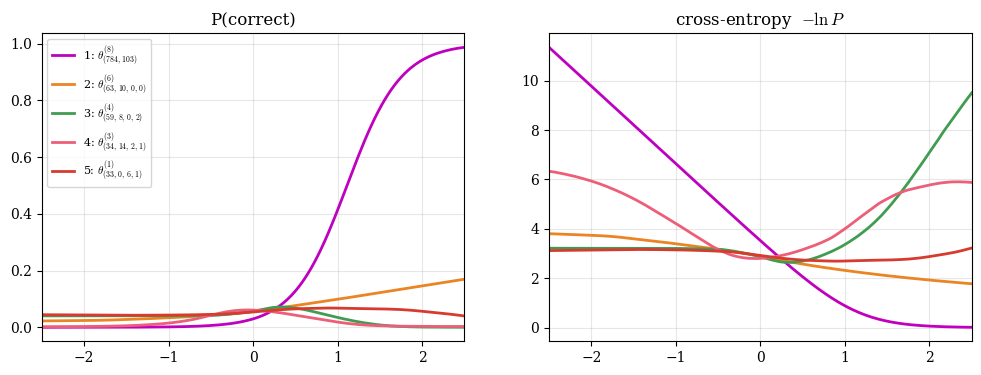

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for p in params.values():
    axes[0].plot(p['vals'], p['res'],  c=p['color'], lw=2, label=f"{p['k']}: {p['theta_label']}")
    axes[1].plot(p['vals'], p['loss'], c=p['color'], lw=2)
axes[0].set_title('P(correct)'); axes[1].set_title(r'cross-entropy  $-\ln P$')
for ax in axes: ax.set_xlim(-SPAN, SPAN); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8);

### Renderers

In [5]:
# geometry identical to the p27 curve frames
FIGSIZE     = (6, 6)
PROB_YLIM   = (-0.05, 1.05)
DPI         = 300
CURVE_LW    = 3
TICK_FS     = 12
PROB_ALPHA_COMBINED = 0.25     # flavor 2
PROB_ALPHA_ONLY     = 1.0     # the prob_only.png overlay base in flavor 1

def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_visible(False)
    ax.tick_params(colors=color, which='both', labelsize=TICK_FS)

def new_fig(facecolor):
    fig = Figure(figsize=FIGSIZE, facecolor=facecolor, dpi=DPI)
    ax = fig.add_subplot(111, facecolor=facecolor)
    ax.set_xlim(-SPAN, SPAN)
    style_ax(ax)
    return fig, ax

def fig_prob_only(p, alpha=PROB_ALPHA_ONLY):
    '''Black bg, P(correct) curve, grid, left ticks 0..1 -- same look as the p27 curve frames.'''
    fig, ax = new_fig('k')
    ax.plot(p['vals'], p['res'], lw=CURVE_LW, c=p['color'], alpha=alpha)
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    # ax.set_ylim(*PROB_YLIM)
    ax.set_ylim(*p['prob_ylim'])
    return fig

def fig_loss_separate(p, upto=None):
    '''Transparent bg, loss curve only, left y-ticks on the loss scale, x-axis kept, no grid.'''
    fig, ax = new_fig('none')
    n = len(p['vals']) if upto is None else upto
    ax.plot(p['vals'][:n], p['loss'][:n], lw=CURVE_LW, c=p['color'])
    ax.set_ylim(*p['loss_ylim'])
    # ax.set_ylim(*p['prob_ylim'])
    return fig

def fig_combined(p, upto=None):
    '''Black bg, P(correct) at reduced alpha on the left axis with grid, loss drawn in on a right axis.'''
    fig, ax = new_fig('k')
    ax.plot(p['vals'], p['res'], lw=CURVE_LW, c=p['color'], alpha=PROB_ALPHA_COMBINED)
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    # ax.set_ylim(*PROB_YLIM)
    ax.set_ylim(*p['prob_ylim'])
    ax2 = ax.twinx()
    n = len(p['vals']) if upto is None else upto
    ax2.plot(p['vals'][:n], p['loss'][:n], lw=CURVE_LW, c=p['color'])
    ax2.set_ylim(*p['loss_ylim'])
    style_ax(ax2)
    ax2.patch.set_alpha(0)
    return fig

def save(fig, path, bbox, transparent=False):
    fig.savefig(path, dpi=DPI, bbox_inches=bbox, transparent=transparent)
    fig.clear()

### One crop box for everything

In [6]:
def tight(fig):
    FigureCanvasAgg(fig)
    return fig.get_tightbbox(fig.canvas.get_renderer())

boxes = []
for p in params.values():
    for f in (fig_prob_only(p), fig_loss_separate(p), fig_combined(p)):
        boxes.append(tight(f)); f.clear()
BBOX = Bbox.union(boxes).padded(0.1)              # savefig(bbox_inches='tight') pads by 0.1 in too
print('crop (inches):', np.round(BBOX.bounds, 3), '->', tuple(int(round(v * DPI)) for v in (BBOX.width, BBOX.height)), 'px')

crop (inches): [0.074 0.298 5.895 5.141] -> (1768, 1542) px


### Preview: final frame of each variant, all five parameters

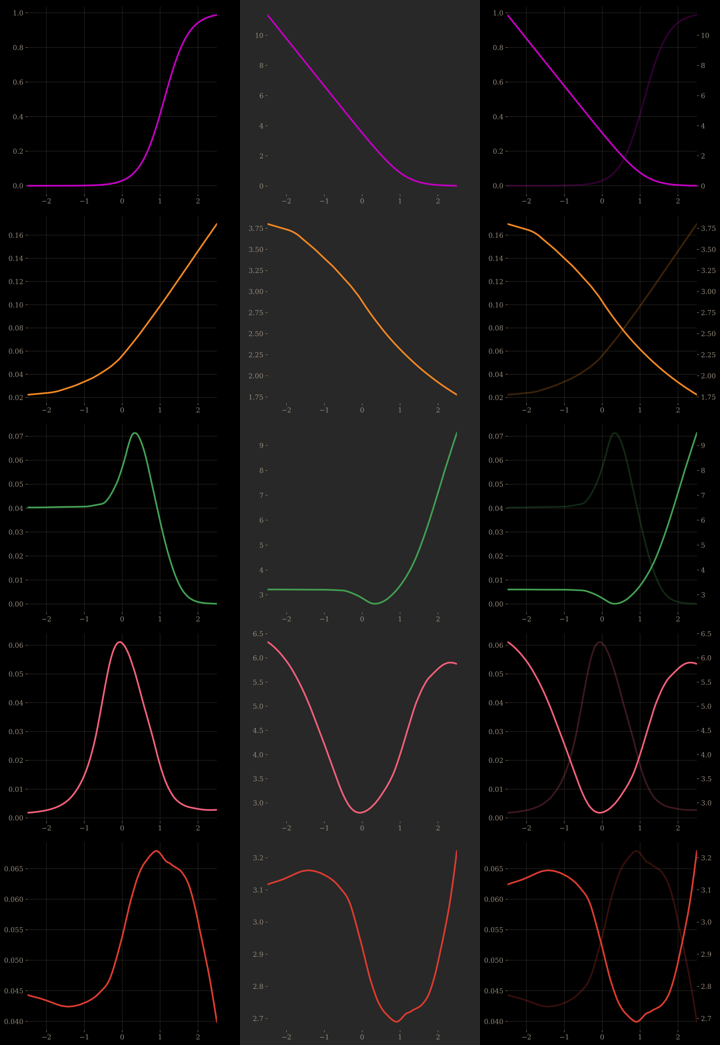

In [7]:
def preview(width=240):
    rows = []
    for p in params.values():
        row = []
        for f, tr in ((fig_prob_only(p), False), (fig_loss_separate(p), True), (fig_combined(p), False)):
            buf = io.BytesIO(); save(f, buf, BBOX, transparent=tr); buf.seek(0)
            im = Image.open(buf).convert('RGBA')
            bg = Image.new('RGBA', im.size, (40, 40, 40, 255)); bg.alpha_composite(im)   # grey behind transparent frames
            row.append(bg.convert('RGB').resize((width, int(width * im.height / im.width))))
        rows.append(row)
    W, H = rows[0][0].size
    sheet = Image.new('RGB', (W * 3, H * len(rows)), 'black')
    for r, row in enumerate(rows):
        for c, im in enumerate(row): sheet.paste(im, (c * W, r * H))
    display(sheet)
preview()

## Render

In [8]:
def write_meta(p, d):
    np.save(d / 'loss.npy', np.stack([p['vals'], p['res'], p['loss']]))
    json.dump({'param': p['k'], 'coord': list(p['coord']), 'layer_num': p['layer_num'], 'theta_label': p['theta_label'],
               'w0': p['w0'], 'color': p['color'], 'n_frames': len(p['vals']), 'span': SPAN,
               'prob_ylim': list(map(float, p['prob_ylim'])),
               'loss_ylim': list(map(float, p['loss_ylim'])), 'prob_ylim': list(PROB_YLIM), 'loss_pad_frac': LOSS_PAD_FRAC,
               'crop_inches': list(map(float, BBOX.bounds)), 'source': str(SWEEP_DIR(p['k']) / 'curve.npy')},
              open(d / 'summary.json', 'w'), indent=2)

def render_separate(p):
    d = OUT_SEPARATE / f"param_{p['k']}"; d.mkdir(parents=True, exist_ok=True)
    save(fig_prob_only(p), d / 'prob_only.png', BBOX)
    for i in tqdm(range(len(p['vals'])), desc=f"separate param {p['k']}", leave=False):
        save(fig_loss_separate(p, upto=i + 1), d / f'frame_{i:03d}.png', BBOX, transparent=True)
        if i % 16 == 0: gc.collect()
    write_meta(p, d)

def render_combined(p):
    d = OUT_COMBINED / f"param_{p['k']}"; d.mkdir(parents=True, exist_ok=True)
    for i in tqdm(range(len(p['vals'])), desc=f"combined param {p['k']}", leave=False):
        save(fig_combined(p, upto=i + 1), d / f'frame_{i:03d}.png', BBOX)
        if i % 16 == 0: gc.collect()
    write_meta(p, d)

for p in params.values():
    render_separate(p)
    render_combined(p)

### Check: every exported PNG is the same size, then a strip through one draw-in

exported pixel sizes: {(1768, 1542)}


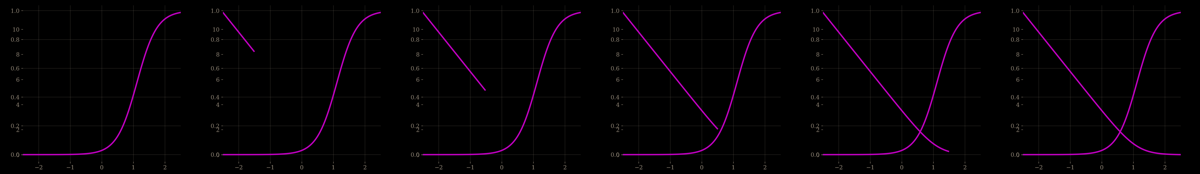

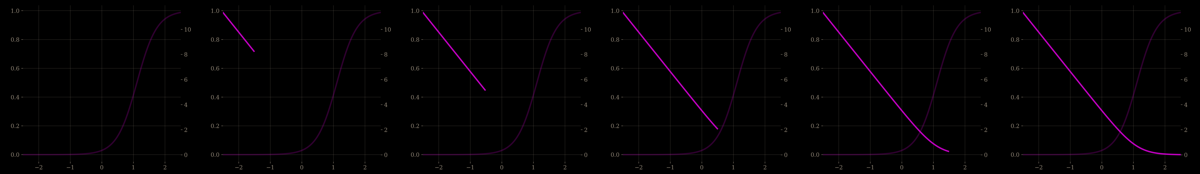

In [9]:
sizes = {Image.open(f).size for root in (OUT_SEPARATE, OUT_COMBINED) for f in root.rglob('*.png')}
print('exported pixel sizes:', sizes)
assert len(sizes) == 1, "frames differ in size!"

k = 1; n = len(params[k]['vals']); picks = np.linspace(0, n - 1, 6).astype(int)
def strip(d, transparent):
    tiles = []
    for i in picks:
        im = Image.open(d / f'frame_{i:03d}.png').convert('RGBA')
        if transparent:
            base = Image.open(d / 'prob_only.png').convert('RGBA'); base.alpha_composite(im); im = base   # what Premiere will see
        tiles.append(im.convert('RGB').resize((200, int(200 * im.height / im.width))))
    W, H = tiles[0].size; sheet = Image.new('RGB', (W * len(tiles), H), 'black')
    for c, t in enumerate(tiles): sheet.paste(t, (c * W, 0))
    display(sheet)
strip(OUT_SEPARATE / f'param_{k}', transparent=True)
strip(OUT_COMBINED / f'param_{k}', transparent=False)